# 06: ElasticNet Regression Training

- Primary model: **ElasticNet** 
- Cross-validation: standard **KFold** and **TimeSeriesSplit**
- Hyperparameter tuning: exhaustive **GridSearchCV** using **TimeSeriesSplit**

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from utils import (
    load_data, 
    train_test_split, 
    visualize_predictions, 
    visualize_feature_importance, 
    train_test_model, 
    visualize_prediction_vs_actual, 
    time_series_grid_search, 
)


sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)


In [10]:
df, feature_cols,target_col =  load_data()
X_train, y_train, X_test, y_test = train_test_split(df, feature_cols, target_col)

Configured target: target_close_1d
Configured features: ['rsi_14', 'macd_hist_12_26_9', 'bb_bandwidth_20_2', 'adx_14', 'obv', 'adj_close_smooth', 'ema_20', 'atr_14', 'volume']
Train rows: 1984
Test rows:  495
Train period: 2016-06-03 -> 2024-04-22
Test period:  2024-04-23 -> 2026-04-14


In [ ]:
# Primary model: ElasticNet (with standardization)
enet_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("enet", ElasticNet(random_state=42)),
    ]
)
pred_train, pred_test, model = train_test_model(enet_model, X_train, y_train, X_test, y_test)

              Model     MAE     RMSE    MAPE      R2
0  Pipeline (train)  8.4328  10.3764  0.1212  0.9662
             Model      MAE   RMSE    MAPE      R2
0  Pipeline (test)  35.1281  37.35  0.1489 -1.0476


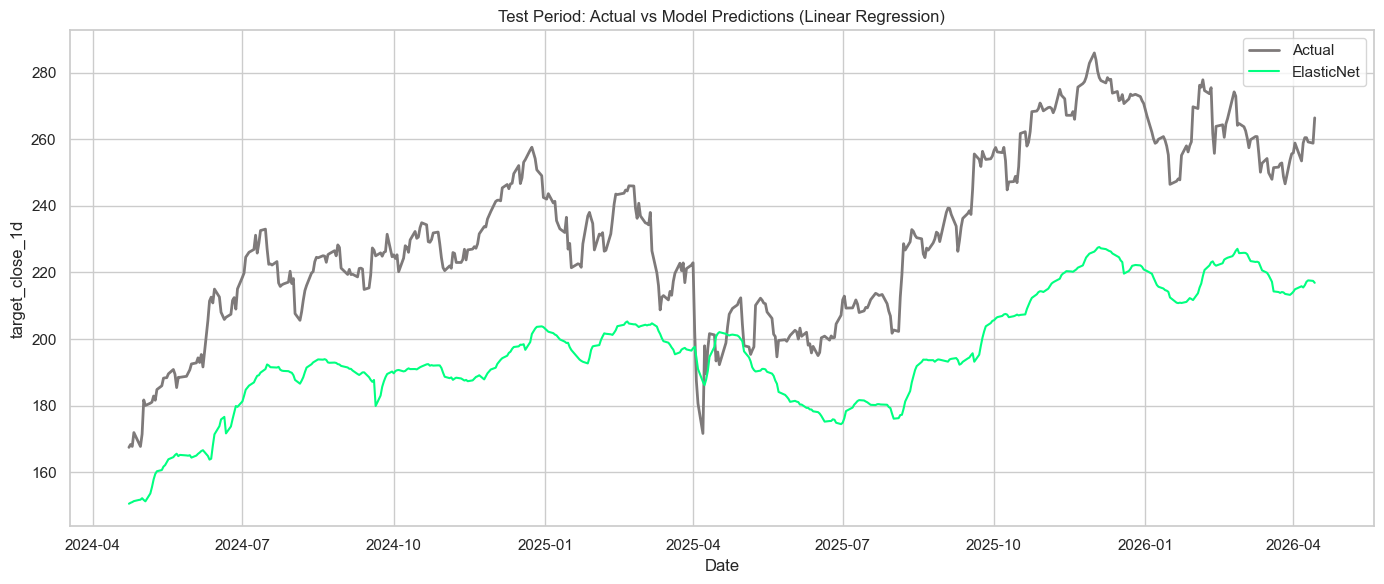

In [12]:
visualize_prediction_vs_actual(y_test, pred_test, target_col, "ElasticNet")

## ElasticNet (TimeSeriesSplit Grid Search)

ElasticNet is trained as a `Pipeline(StandardScaler → ElasticNet)` so features are standardized before fitting (important for regularized linear models). We tune hyperparameters using an exhaustive grid search with `TimeSeriesSplit`, then refit the best configuration on the full training set and generate predictions on the held-out test period.

Hyperparameters tuned:
- `enet__alpha`: overall regularization strength (higher = more shrinkage, simpler model).
- `enet__l1_ratio`: mix between L1 and L2 penalties (`0` ≈ Ridge-like, `1` ≈ Lasso-like); controls sparsity vs. smooth shrinkage.

Output:
- `best_estimator`: the tuned pipeline (`StandardScaler` + `ElasticNet`) with the best CV settings.
- `best_pred_test`: test-period predictions from the tuned model.

In [13]:
enet_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("enet", ElasticNet()),
    ]
)

param_grid = {
    "enet__alpha": np.logspace(-5, 1, 7),
    "enet__l1_ratio": [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.85, 0.9, 0.95, 0.99],
}


best_estimator, best_pred_test = time_series_grid_search(
    enet_model, param_grid, X_train, y_train, X_test, y_test
)


Fitting 5 folds for each of 70 candidates, totalling 350 fits
Best CV root_mean_squared_error: 2.598945368541424
Best params: {'enet__alpha': np.float64(0.01), 'enet__l1_ratio': 0.99}
                                  Model     MAE    RMSE    MAPE      R2
0  Pipeline (tuned via TimeSeriesSplit)  4.0453  5.4991  0.0178  0.9556


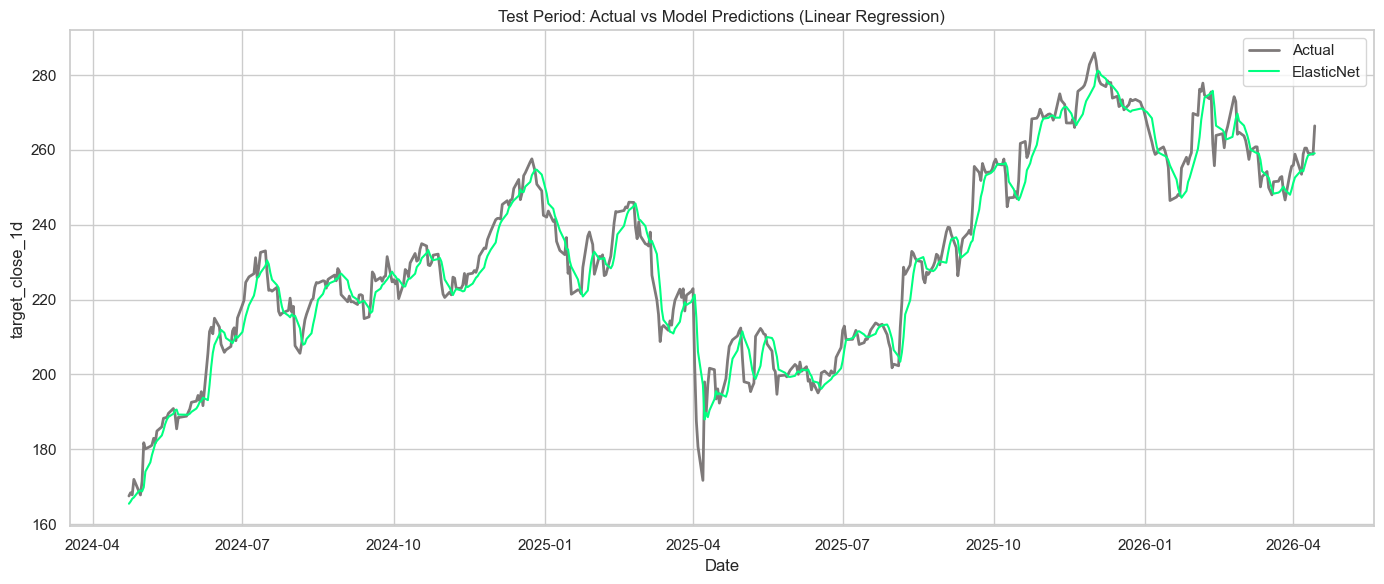

In [14]:
visualize_prediction_vs_actual(y_test, best_pred_test, target_col, "ElasticNet")

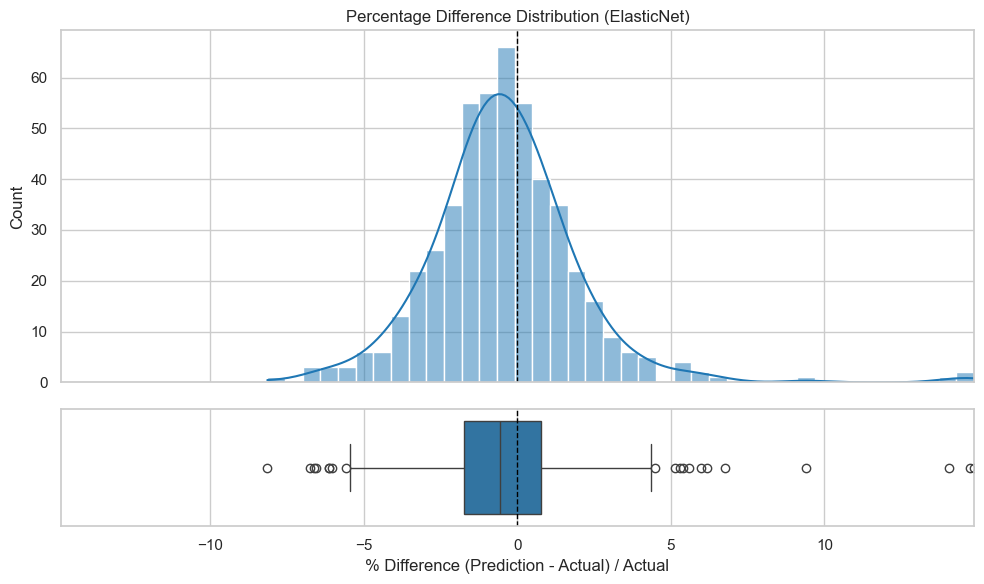

In [15]:
visualize_predictions(y_test, best_pred_test, "ElasticNet")

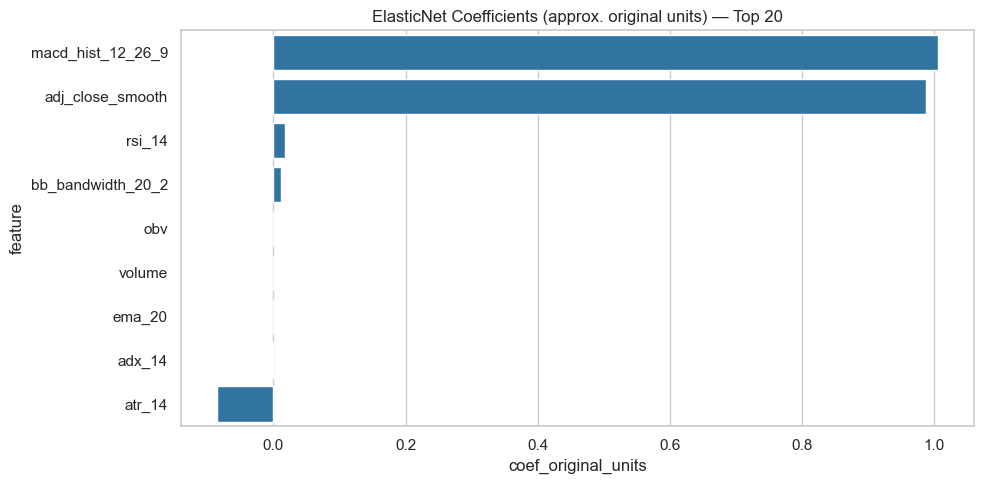

,feature,coef_scaled,coef_original_units
0,macd_hist_12_26_9,0.567398,1.005730e+00
1,adj_close_smooth,55.691031,9.879523e-01
2,rsi_14,0.449870,1.810534e-02
3,bb_bandwidth_20_2,0.055436,1.112486e-02
4,obv,0.808917,6.017786e-11
5,volume,-0.000000,-0.000000e+00
6,ema_20,0.000000,0.000000e+00
7,adx_14,-0.039843,-2.286653e-03
8,atr_14,-0.088636,-8.538737e-02


In [16]:
# Coefficients
scaler = best_estimator.named_steps["scaler"]
enet = best_estimator.named_steps["enet"]

visualize_feature_importance(enet, scaler, feature_cols, "ElasticNet")
